In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Operator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.compiler import transpile
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_aer.primitives import SamplerV2
from qiskit_aer import AerSimulator
from matplotlib import pyplot as plt
from qiskit.circuit.library import RealAmplitudes
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import UnitaryGate
import numpy as np
import matplotlib.ticker as ticker
from scipy.linalg import svd
from qiskit.quantum_info import Statevector
import scipy.linalg
from scipy.linalg import qr

In [2]:
simulator = AerSimulator()

<>:97: SyntaxWarning: invalid escape sequence '\m'
<>:98: SyntaxWarning: invalid escape sequence '\m'
<>:99: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
<>:97: SyntaxWarning: invalid escape sequence '\m'
<>:98: SyntaxWarning: invalid escape sequence '\m'
<>:99: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
/var/folders/sv/wfk5zngj3bv7b7v1ypmr9d_w0000gn/T/ipykernel_7993/1321528682.py:97: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(glb_E_NH_dcpm90, glb_P_nue_NH_dcpm90, '--', color='blue', linewidth=2, label='GLoBES P($\nu_\mu \to \nu_e$), NH, $\delta_{CP}=-90^\circ$')
/var/folders/sv/wfk5zngj3bv7b7v1ypmr9d_w0000gn/T/ipykernel_7993/1321528682.py:98: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(glb_E_NH_dcp90, glb_P_nue_NH_dcp90, '--', color='red', linewidth=2, label='GLoBES P($\nu_\mu \to \nu_e$), NH, $\delta_{CP}=90^\circ$')
/var/folders/sv/wfk5zngj3bv7b7v1ypmr9d_w00

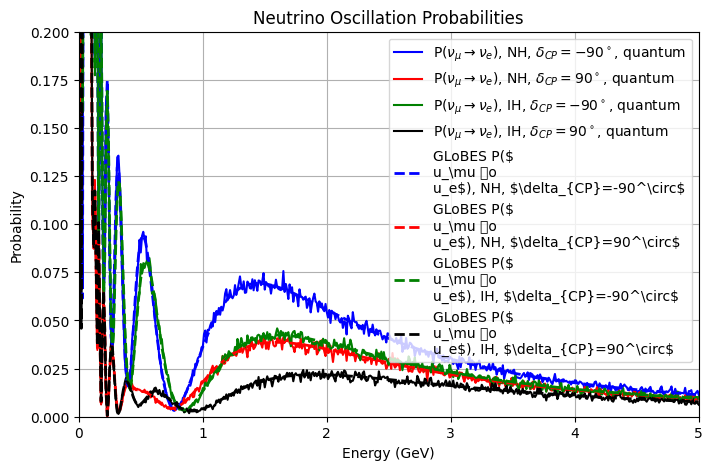

In [9]:
# Define mixing angles (in radians) and constants

theta_12, theta_13, theta_23 = np.radians([33.68, 8.56, 43.3])
particle = "particle"
cp_sign = 1 if particle == "particle" else -1

# PMNS matrix generator
def PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP):
    c = np.cos([theta_12, theta_13, theta_23])
    s = np.sin([theta_12, theta_13, theta_23])
    c12, c13, c23 = c
    s12, s13, s23 = s
    e_idelta = np.exp(-1j * delta_CP * cp_sign)
    e_ideltap = np.exp(1j * delta_CP * cp_sign)

    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s23 * s13 * e_ideltap, c12 * c23 - s12 * s23 * s13 * e_ideltap, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * e_ideltap, -c12 * s23 - s12 * c23 * s13 * e_ideltap, c23 * c13]
    ], dtype=complex)

    U_4x4 = np.eye(4, dtype=complex)
    U_4x4[:3, :3] = U
    return U_4x4

# Constants
G_F, sqrt2, rho, Ye = 1.166e-5, np.sqrt(2), 2.8, 0.5
Na, sDm2 = 6.022e23, 7.49e-5 #eV^2
hbar, c = 6.582e-16, 3e8 #eVs, m/s
L, t = 810e3, 810e3 / c #NOvA baseline=810 km converted to m
Vcc = 0.5 * 7.6e-14 * rho #cp_sign * 7.6e-15 * rho #eV
E_values = np.arange(0.01, 5.001, 0.01)

# Probability calculator
def calculate_probabilities(delta_CP, hierarchy="NH"):
    if hierarchy == "NH":
        lDm2 = 2.513e-3
    elif hierarchy == "IH":
        lDm2 = -2.484e-3 + sDm2
    else:
        raise ValueError("Hierarchy must be 'NH' or 'IH'")

    m1, m2, m3 = 0, sDm2  , lDm2  
    M2_3x3 = np.diag([m1, m2, m3])
    U_PMNS_3x3 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)[:3, :3]
    E_list, P_nue_list, P_numu_list, P_nutau_list = [], [], [], []

    for E in E_values:
        qc = QuantumCircuit(2, 2)
        qc.x(0)  # Initial state: nu_mu
        state = Statevector.from_instruction(qc)

        H_vac = U_PMNS_3x3 @ M2_3x3 @ U_PMNS_3x3.conj().T
        V = np.diag([ Vcc, 0, 0])
        H_flavour = (H_vac) / (2 * E * 1e9)+V
        eigvals, eigvecs = np.linalg.eigh(H_flavour)

        U_eff, evolution = np.eye(4, dtype=complex), np.eye(4, dtype=complex)
        U_eff[:3, :3] = eigvecs
        evolution[:3, :3] = np.diag(np.exp(-1j * eigvals * t/hbar))

        qc.unitary(UnitaryGate(U_eff.T.conj(), label="U"), [0, 1])
        state = Statevector.from_instruction(qc)
        qc.unitary(UnitaryGate(evolution, label="e^(-iHt)"), [0, 1])
        state = Statevector.from_instruction(qc)
        qc.unitary(UnitaryGate(U_eff, label="U†"), [0, 1])
        state = Statevector.from_instruction(qc)
        qc.measure([0, 1], [0, 1])

        pqc = transpile(qc, simulator)
        counts = simulator.run(pqc, shots=8192).result().get_counts()
        total = sum(counts.get(state, 0) for state in ['00', '01', '10'])

        E_list.append(E)
        P_nue_list.append(counts.get('00', 0) / total)
        P_numu_list.append(counts.get('01', 0) / total)
        P_nutau_list.append(counts.get('10', 0) / total)

    return E_list, P_nue_list, P_numu_list, P_nutau_list

# Compute for delta_CP = -90 and +90
E_list_NH_dcpm90, P_nue_NH_dcpm90, _, _ = calculate_probabilities(np.radians(-90), hierarchy="NH")
E_list_NH_dcp90, P_nue_NH_dcp90, _, _ = calculate_probabilities(np.radians(90), hierarchy="NH")
E_list_IH_dcpm90, P_nue_IH_dcpm90, _, _ = calculate_probabilities(np.radians(-90), hierarchy="IH")
E_list_IH_dcp90, P_nue_IH_dcp90, _, _ = calculate_probabilities(np.radians(90), hierarchy="IH")
# Load GLoBES results
glb_E_NH_dcpm90, glb_P_nue_NH_dcpm90, _, _ = np.loadtxt("prob_nue_numu_NOvA_initial_numu_matter_NH_dcp-90.dat", unpack=True)
glb_E_NH_dcp90, glb_P_nue_NH_dcp90, _, _ = np.loadtxt("prob_nue_numu_NOvA_initial_numu_matter_NH_dcp90.dat", unpack=True)
glb_E_IH_dcpm90, glb_P_nue_IH_dcpm90, _, _ = np.loadtxt("prob_nue_numu_NOvA_initial_numu_matter_IH_dcp-90.dat", unpack=True)
glb_E_IH_dcp90, glb_P_nue_IH_dcp90, _, _ = np.loadtxt("prob_nue_numu_NOvA_initial_numu_matter_IH_dcp90.dat", unpack=True)
# Plot
plt.figure(figsize=(8, 5))
plt.plot(E_list_NH_dcpm90, P_nue_NH_dcpm90, '-', color='blue', label=r'P($\nu_\mu \to \nu_e$), NH, $\delta_{CP}=-90^\circ$, quantum')
plt.plot(E_list_NH_dcp90, P_nue_NH_dcp90, '-', color='red', label=r'P($\nu_\mu \to \nu_e$), NH, $\delta_{CP}=90^\circ$, quantum')
plt.plot(E_list_IH_dcpm90, P_nue_IH_dcpm90, '-', color='green', label=r'P($\nu_\mu \to \nu_e$), IH, $\delta_{CP}=-90^\circ$, quantum')
plt.plot(E_list_IH_dcp90, P_nue_IH_dcp90, '-', color='black', label=r'P($\nu_\mu \to \nu_e$), IH, $\delta_{CP}=90^\circ$, quantum')
plt.plot(glb_E_NH_dcpm90, glb_P_nue_NH_dcpm90, '--', color='blue', linewidth=2, label='GLoBES P($\nu_\mu \to \nu_e$), NH, $\delta_{CP}=-90^\circ$')
plt.plot(glb_E_NH_dcp90, glb_P_nue_NH_dcp90, '--', color='red', linewidth=2, label='GLoBES P($\nu_\mu \to \nu_e$), NH, $\delta_{CP}=90^\circ$')
plt.plot(glb_E_IH_dcpm90, glb_P_nue_IH_dcpm90, '--', color='green', linewidth=2, label='GLoBES P($\nu_\mu \to \nu_e$), IH, $\delta_{CP}=-90^\circ$')
plt.plot(glb_E_IH_dcp90, glb_P_nue_IH_dcp90, '--', color='black', linewidth=2, label='GLoBES P($\nu_\mu \to \nu_e$), IH, $\delta_{CP}=90^\circ$')
plt.xlim(0, 5)
plt.ylim(0, 0.2)
plt.xlabel("Energy (GeV)")
plt.ylabel("Probability")
plt.title("Neutrino Oscillation Probabilities")
plt.legend()
plt.grid()
plt.show()
